C:\Users\edier\AppData\Local\Temp\ipykernel_18184\2311968608.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cuenca', y='residual', ax=axes[0, 0], data=data_cuenca,
C:\Users\edier\AppData\Local\Temp\ipykernel_18184\2311968608.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='knn5', y='residual', ax=axes[1, 0], data=data_knn5,


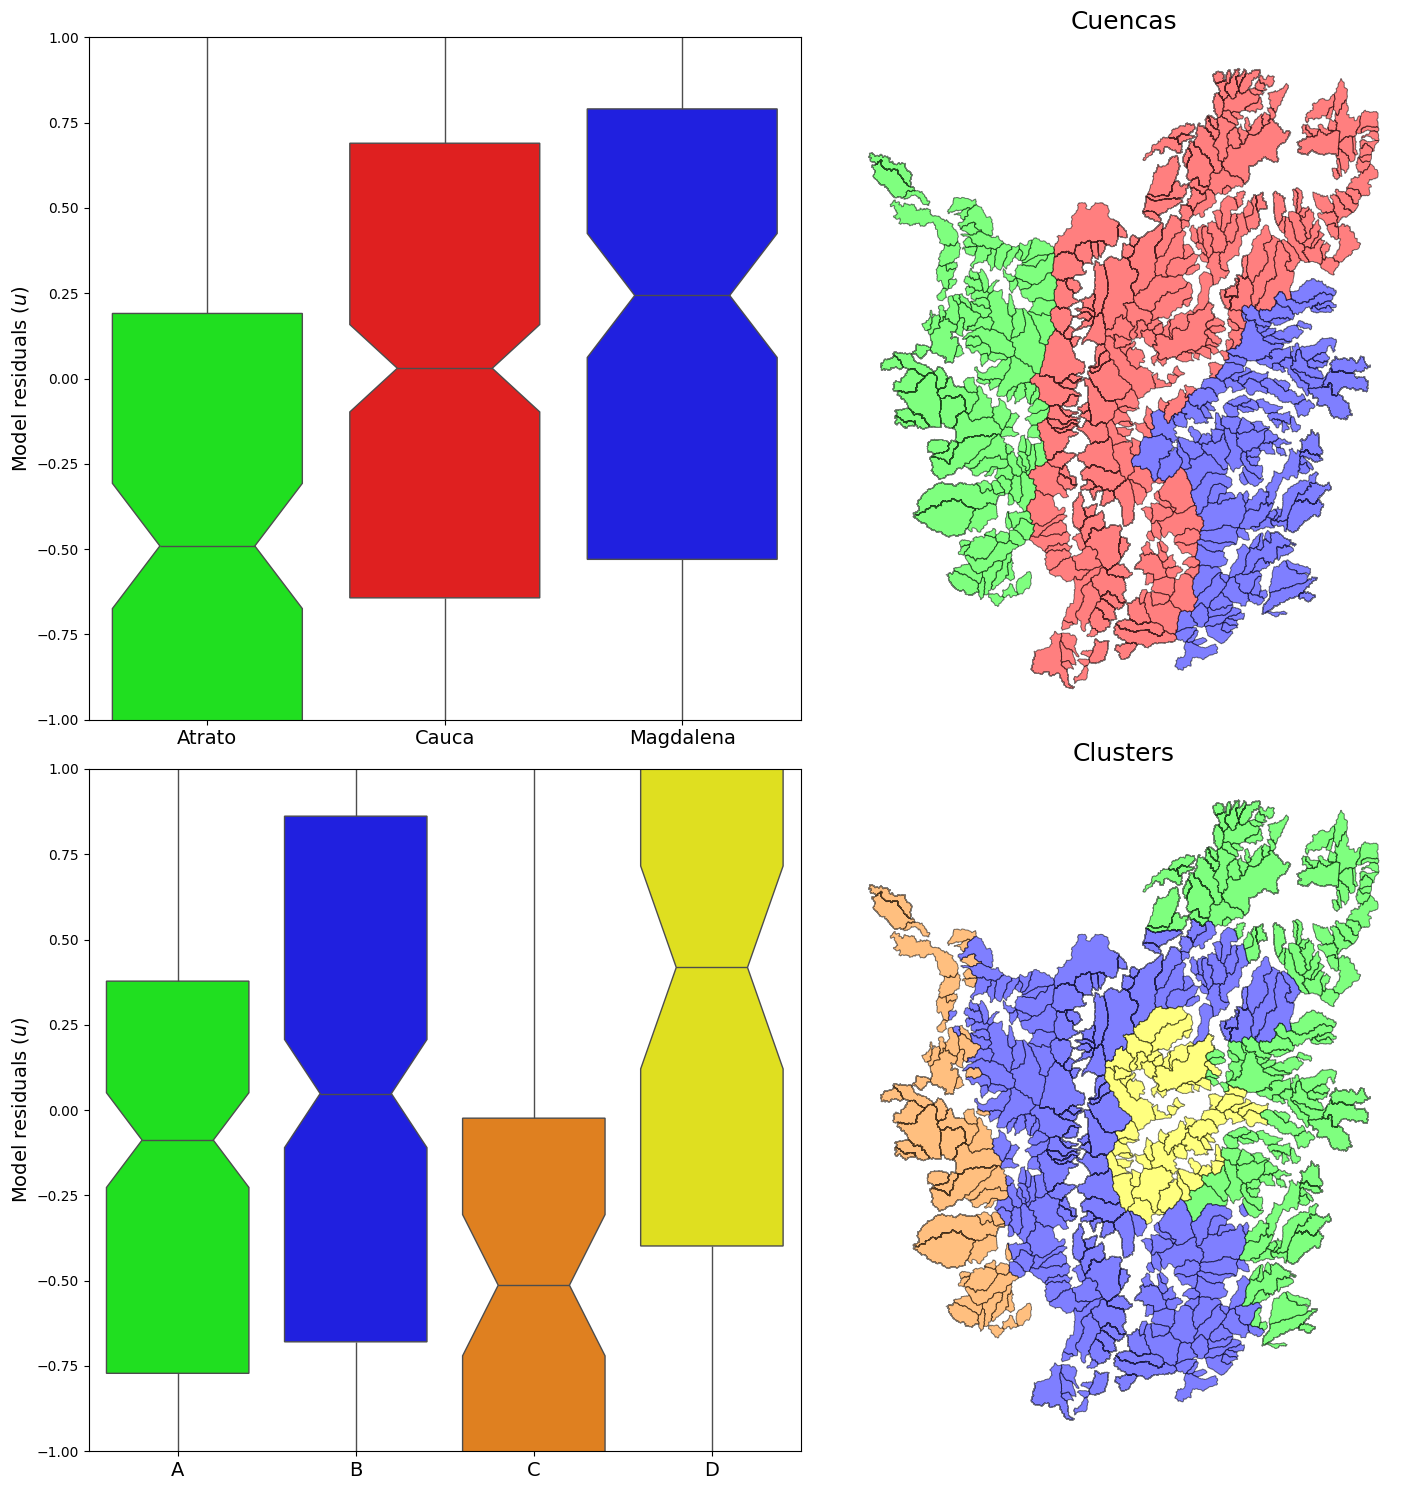

In [9]:
# Crear figura con 2 filas y 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(15, 15))

# Boxplot para 'cuenca'
sns.boxplot(x='cuenca', y='residual', ax=axes[0, 0], data=data_cuenca,
            palette=my_pal_cuenca, notch=True, order=["Atrato", "Cauca", "Magdalena"])
axes[0, 0].tick_params(axis='x', labelsize=14)
axes[0, 0].set_ylim(-1, 1)
axes[0, 0].set_ylabel("Model residuals ($u$)", fontsize=14)
axes[0, 0].set_xlabel("")

# Boxplot para 'knn5'
sns.boxplot(x='knn5', y='residual', ax=axes[1, 0], data=data_knn5,
            palette=my_pal_knn5, notch=True, order=["A", "B", "C", "D"])
axes[1, 0].tick_params(axis='x', labelsize=14)
axes[1, 0].set_ylim(-1, 1)
axes[1, 0].set_ylabel("Model residuals ($u$)", fontsize=14)
axes[1, 0].set_xlabel("")

# Mapa de cuencas con colores sólidos en lugar de escala continua
gdf['color_cuenca'] = gdf['cuenca'].map(my_pal_cuenca)  # Asignar colores según cuenca
gdf.plot(color=gdf['color_cuenca'], ax=axes[0, 1], edgecolor='black', linewidth=0.7, alpha=0.5)
axes[0, 1].set_title("Cuencas", fontsize=18)
axes[0, 1].set_axis_off()

# Mapa de clusters con colores sólidos
gdf['color_knn5'] = gdf['knn5'].map(my_pal_knn5)  # Asignar colores según cluster
gdf.plot(color=gdf['color_knn5'], ax=axes[1, 1], edgecolor='black', linewidth=0.7, alpha=0.5)
axes[1, 1].set_title("Clusters", fontsize=18)
axes[1, 1].set_axis_off()

# Ajustar diseño y guardar la figura
plt.tight_layout()
plt.savefig('G:/My Drive/INVESTIGACION/PAPERS/ELABORACION/PAPER_SAR/Figures/residuals_boxplot_adjusted2.png', dpi=500, bbox_inches='tight')

plt.show();

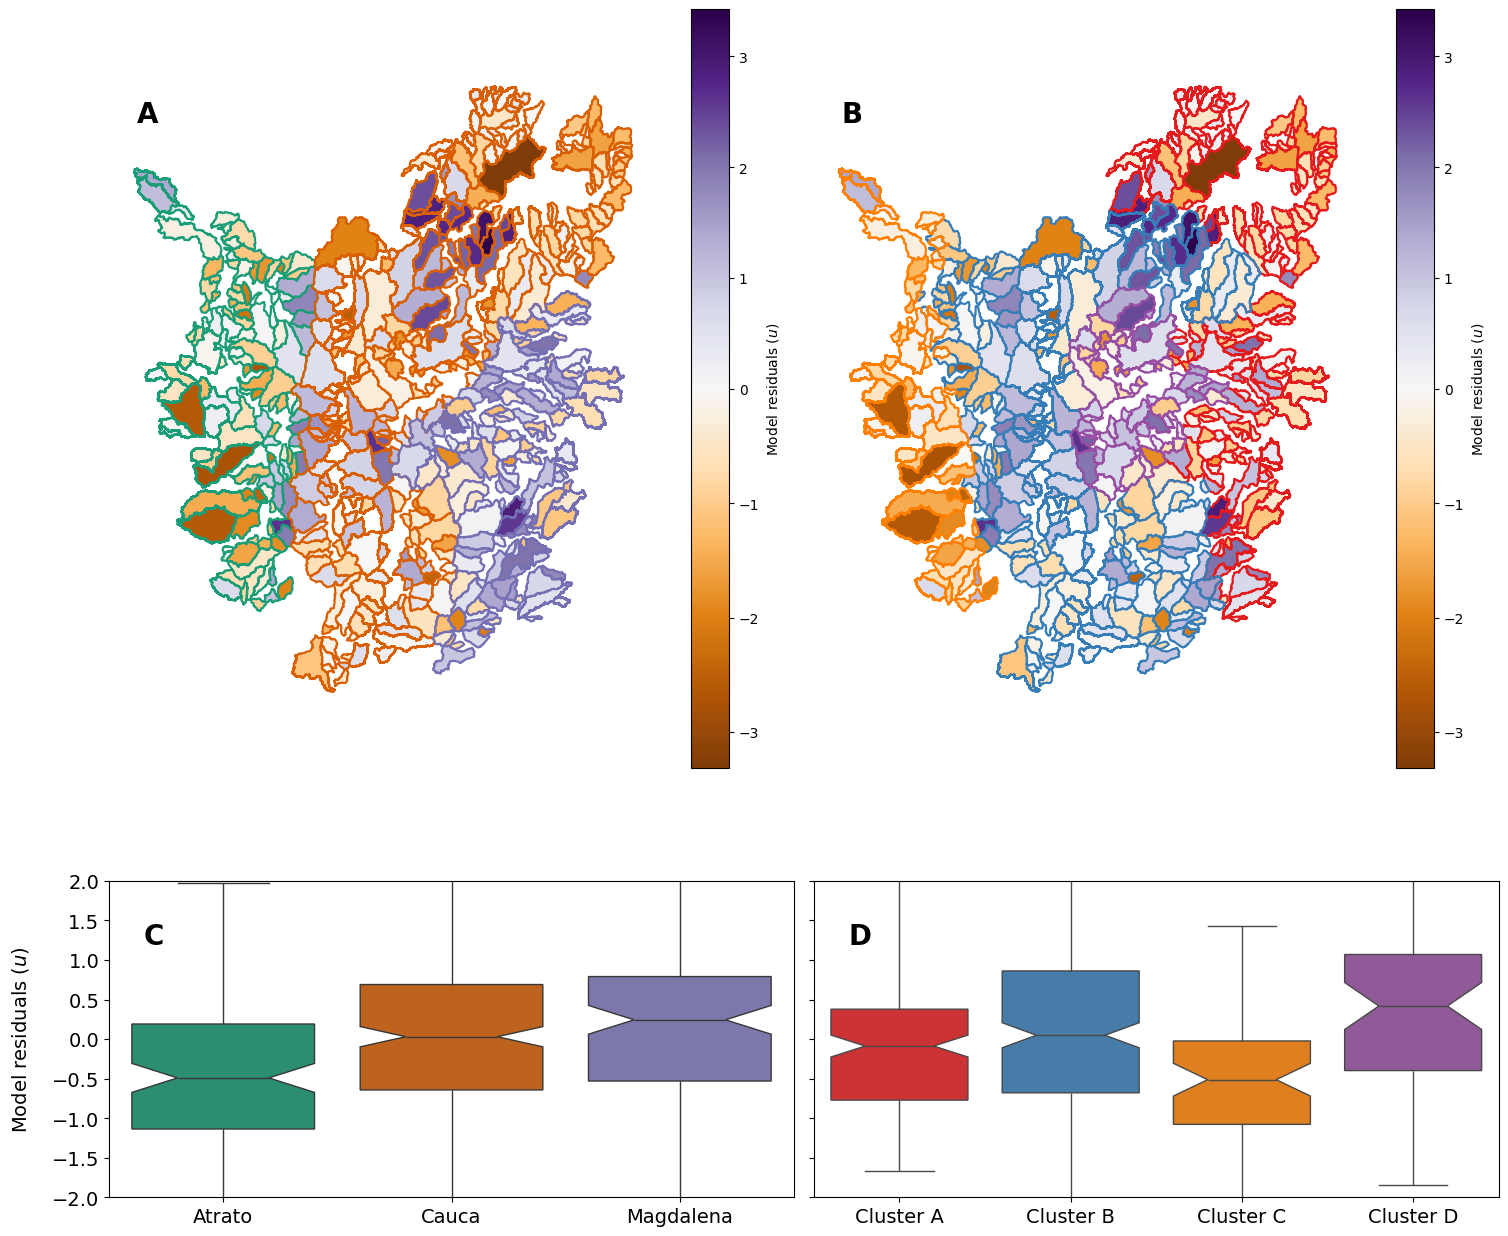

In [4]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import spreg
from matplotlib.colors import TwoSlopeNorm

# Cargar datos
gdf = gpd.read_file("/home/edier/GoogleDrive/INVESTIGACION/PAPERS/ELABORACION/PAPER_SAR/Data/df_catchments_kmeans.gpkg")

# Preparar datos
gdf["y_log"] = np.log(gdf['lands_rec'] + 1)
var = ['area', 'elev_mean', 'rel_mean']

# Escalar variables
st = StandardScaler()
X = st.fit_transform(gdf[var])

# Preparar variable dependiente
y = np.array(gdf["y_log"])
y.shape = (len(gdf), 1)

# Ajustar modelo OLS
m1 = spreg.OLS(y, X, name_y='Landslide_density', name_x=var)
gdf['residual'] = m1.u

# Calcular medianas de residuales por 'cuenca' y 'knn5'
medians_cuenca = gdf.groupby("cuenca").residual.median().to_frame('basin_residual')
data_cuenca = gdf.merge(medians_cuenca, how='left', left_on='cuenca', right_index=True)

medians_knn5 = gdf.groupby("knn5").residual.median().to_frame('basin_residual')
data_knn5 = gdf.merge(medians_knn5, how='left', left_on='knn5', right_index=True)

# Renombrar clusters en los datos
cluster_names = {"A": "Cluster A", "B": "Cluster B", "C": "Cluster C", "D": "Cluster D"}
gdf["knn5"] = gdf["knn5"].map(cluster_names)
data_knn5["knn5"] = data_knn5["knn5"].map(cluster_names)

# Paletas de colores únicas y distintas
my_pal_cuenca = {"Atrato": "#1b9e77", "Cauca": "#d95f02", "Magdalena": "#7570b3"} # Tonos Verde, Naranja Oscuro, Púrpura
my_pal_knn5 = {"Cluster A": "#e41a1c", "Cluster B": "#377eb8",
               "Cluster C": "#ff7f00", "Cluster D": "#984ea3"} # Tonos Rojo, Azul, Naranja, Morado

# Nueva disposición de la figura
fig, axes = plt.subplots(2, 2, figsize=(15, 15), gridspec_kw={'height_ratios': [4, 1]})


# --- FILA 1: MAPAS ---

# Mapa de residuales coloreados con contornos por cuenca
norm = TwoSlopeNorm(vmin=gdf['residual'].min(), vcenter=0, vmax=gdf['residual'].max())
gdf.plot(column='residual', cmap='PuOr', norm=norm, ax=axes[0, 0], legend=True,
         legend_kwds={'label': "Model residuals ($u$)", 'shrink': 0.6})
for cuenca, color in my_pal_cuenca.items():
    gdf[gdf['cuenca'] == cuenca].boundary.plot(ax=axes[0, 0], color=color, linewidth=1.5)
axes[0, 0].set_axis_off()
axes[0, 0].text(0.05, 0.9, "A", transform=axes[0, 0].transAxes, fontsize=20, fontweight='bold')

# Mapa de residuales coloreados con contornos por cluster
gdf.plot(column='residual', cmap='PuOr', norm=norm, ax=axes[0, 1], legend=True,
         legend_kwds={'label': "Model residuals ($u$)", 'shrink': 0.6})
for knn5, color in my_pal_knn5.items():
    gdf[gdf['knn5'] == knn5].boundary.plot(ax=axes[0, 1], color=color, linewidth=1.5)
axes[0, 1].set_axis_off()
axes[0, 1].text(0.05, 0.9, "B", transform=axes[0, 1].transAxes, fontsize=20, fontweight='bold')


# --- FILA 2: BOXPLOTS ---

# Boxplot para 'cuenca'
sns.boxplot(x='cuenca', y='residual', ax=axes[1, 0], data=data_cuenca,
            hue='cuenca', palette=my_pal_cuenca, notch=True, order=["Atrato", "Cauca", "Magdalena"], legend=False)
axes[1, 0].tick_params(axis='x', labelsize=14)
# MODIFICACIÓN: Rango del eje Y ampliado a (-2, 2)
axes[1, 0].set_ylim(-2, 2)
axes[1, 0].set_ylabel("Model residuals ($u$)", fontsize=14)
axes[1, 0].set_xlabel("")
axes[1, 0].text(0.05, 0.8, "C", transform=axes[1, 0].transAxes, fontsize=20, fontweight='bold')

# Boxplot para 'knn5'
sns.boxplot(x='knn5', y='residual', ax=axes[1, 1], data=data_knn5,
            hue='knn5', palette=my_pal_knn5, notch=True, order=["Cluster A", "Cluster B", "Cluster C", "Cluster D"], legend=False)
axes[1, 1].tick_params(axis='x', labelsize=14)
# MODIFICACIÓN: Rango del eje Y ampliado a (-2, 2)
axes[1, 1].set_ylim(-2, 2)
axes[1, 1].set_ylabel("") # Sin etiqueta Y para evitar redundancia
axes[1, 1].set_xlabel("")
# MODIFICACIÓN: Se eliminan los números (tick labels) del eje Y
axes[1, 1].tick_params(axis='y', labelleft=False)
axes[1, 1].text(0.05, 0.8, "D", transform=axes[1, 1].transAxes, fontsize=20, fontweight='bold')


# Ajustar el tamaño de las leyendas de AMBAS barras de color
for ax in [axes[0,0], axes[0,1]]:
    cbar_ax = ax.get_figure().get_axes()[ax.get_figure().get_axes().index(ax) + 1]
    cbar_ax.tick_params(labelsize=14)
    # MODIFICACIÓN: Rotación de la etiqueta a 90 grados (de abajo hacia arriba)
    cbar_ax.set_ylabel("Model residuals ($u$)", fontsize=14, rotation=90, labelpad=15)


# Ajustar el espaciado final de la figura
fig.tight_layout()
plt.savefig('/home/edier/GoogleDrive/INVESTIGACION/PAPERS/ELABORACION/PAPER_SAR/Figures/figFinal/Fig8.png', dpi=500, bbox_inches='tight')
plt.show()

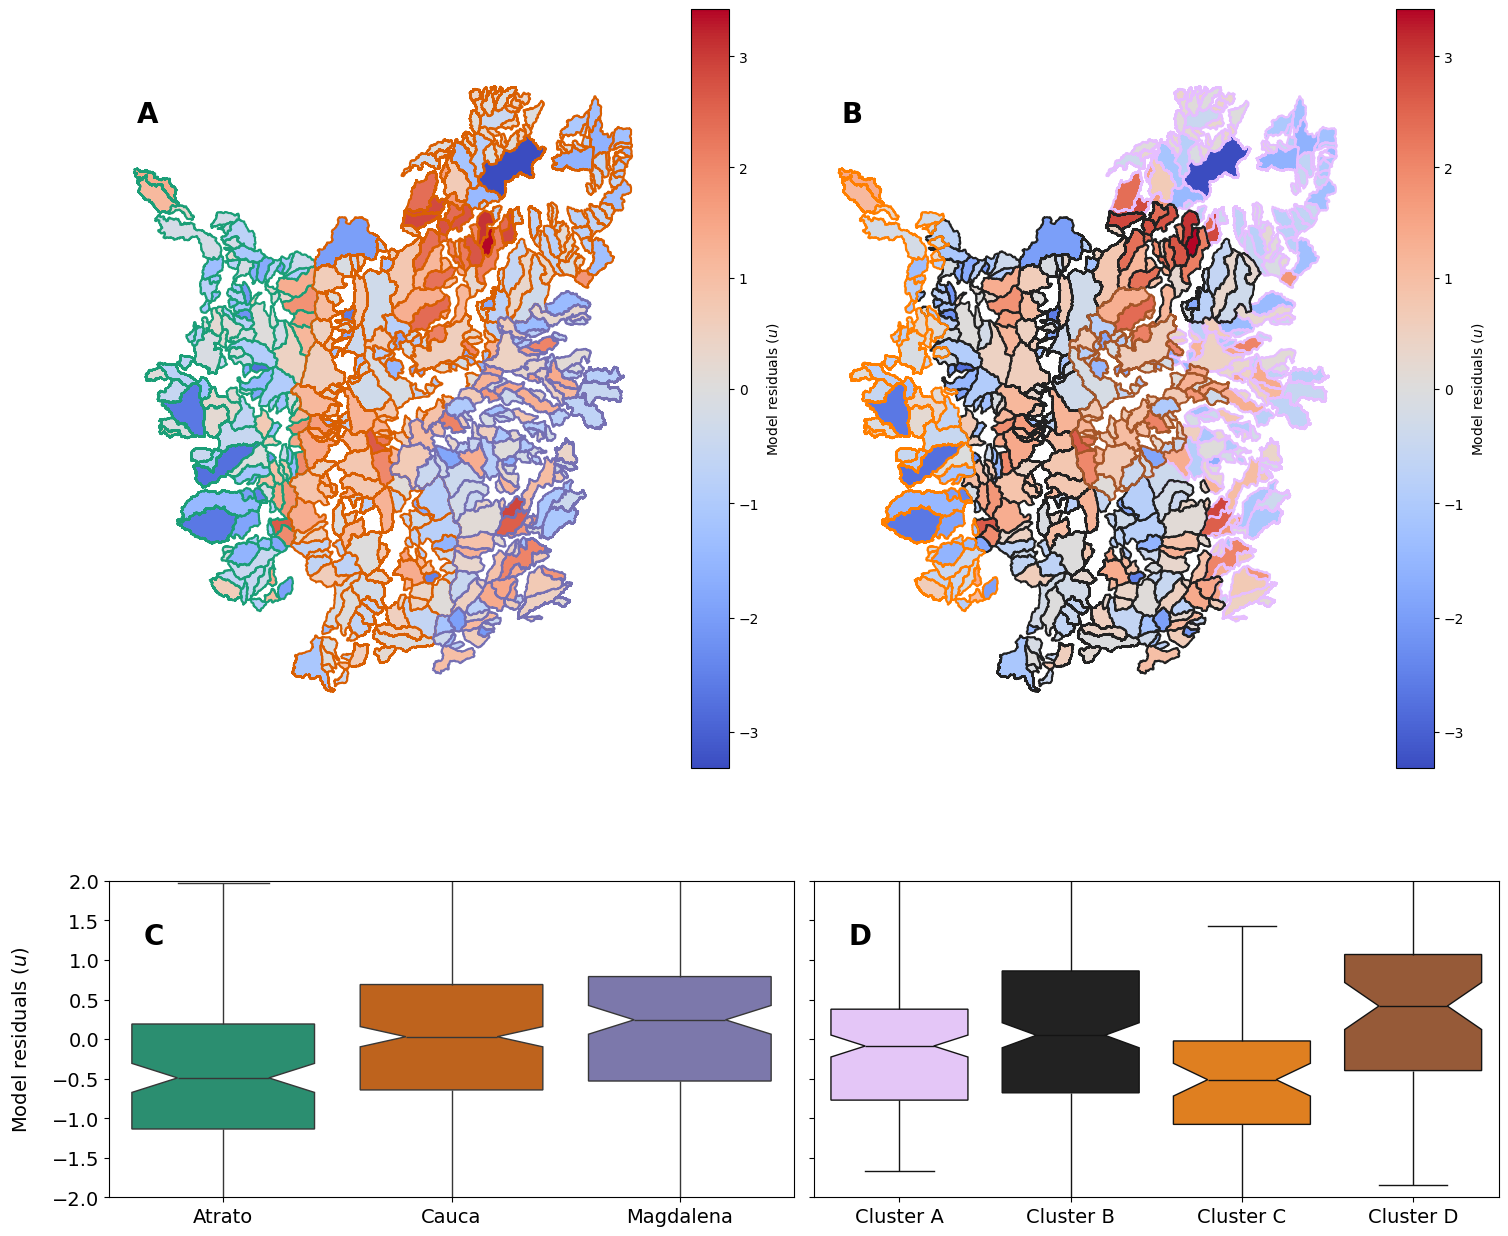

In [3]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import spreg
from matplotlib.colors import TwoSlopeNorm

# Cargar datos
# Make sure the path to your file is correct
try:
    gdf = gpd.read_file("/home/edier/GoogleDrive/INVESTIGACION/PAPERS/ELABORACION/PAPER_SAR/Data/df_catchments_kmeans.gpkg")
except Exception as e:
    print(f"Could not load the file. Using example data. Error: {e}")
    # Create an example DataFrame if the file is not found
    from shapely.geometry import Polygon
    p1 = Polygon([(0, 0), (1, 0), (1, 1), (0, 1)])
    p2 = Polygon([(2, 2), (3, 2), (3, 3), (2, 3)])
    p3 = Polygon([(0, 2), (1, 2), (1, 3), (0, 3)])
    gdf = gpd.GeoDataFrame({
        'lands_rec': [10, 5, 12, 8, 15, 2, 20, 3],
        'area': [1.1, 1.2, 1.0, 1.3, 1.5, 0.9, 1.8, 0.8],
        'elev_mean': [100, 110, 95, 120, 130, 90, 150, 85],
        'rel_mean': [50, 55, 48, 60, 65, 45, 70, 42],
        'cuenca': ['Atrato', 'Cauca', 'Magdalena', 'Atrato', 'Cauca', 'Magdalena', 'Cauca', 'Atrato'],
        'knn5': ['A', 'B', 'C', 'D', 'A', 'B', 'C', 'D'],
        'geometry': [p1, p2, p3, p1.buffer(0.5), p2.buffer(0.5), p3.buffer(0.5), p2.buffer(0.2), p1.buffer(0.2)]
    })

# Preparar datos
gdf["y_log"] = np.log(gdf['lands_rec'] + 1)
var = ['area', 'elev_mean', 'rel_mean']

# Escalar variables
st = StandardScaler()
X = st.fit_transform(gdf[var])

# Preparar variable dependiente
y = np.array(gdf["y_log"])
y.shape = (len(gdf), 1)

# Ajustar modelo OLS
m1 = spreg.OLS(y, X, name_y='Landslide_density', name_x=var)
gdf['residual'] = m1.u

# Calcular medianas de residuales por 'cuenca' y 'knn5'
medians_cuenca = gdf.groupby("cuenca").residual.median().to_frame('basin_residual')
data_cuenca = gdf.merge(medians_cuenca, how='left', left_on='cuenca', right_index=True)

medians_knn5 = gdf.groupby("knn5").residual.median().to_frame('basin_residual')
data_knn5 = gdf.merge(medians_knn5, how='left', left_on='knn5', right_index=True)

# Renombrar clusters en los datos
cluster_names = {"A": "Cluster A", "B": "Cluster B", "C": "Cluster C", "D": "Cluster D"}
gdf["knn5"] = gdf["knn5"].map(cluster_names)
data_knn5["knn5"] = data_knn5["knn5"].map(cluster_names)

# --- MODIFICATION: Adjusted color palettes to ensure no overlap ---
# Paletas de colores únicas y distintas
my_pal_cuenca = {"Atrato": "#1b9e77", "Cauca": "#d95f02", "Magdalena": "#7570b3"} # Green, Dark Orange, Purple
# Cluster colors adjusted to avoid clashing with the 'coolwarm' colormap
my_pal_knn5 = {"Cluster A": "#e6beff", "Cluster B": "#222222",
               "Cluster C": "#ff7f00", "Cluster D": "#a65628"} # Light Purple, Black, Orange, Brown

# Nueva disposición de la figura
fig, axes = plt.subplots(2, 2, figsize=(15, 15), gridspec_kw={'height_ratios': [4, 1]})


# --- FILA 1: MAPAS ---

# Mapa de residuales coloreados con contornos por cuenca
norm = TwoSlopeNorm(vmin=gdf['residual'].min(), vcenter=0, vmax=gdf['residual'].max())
# MODIFICATION: Changed colormap to 'coolwarm' (Blue-Red) for clear divergence
gdf.plot(column='residual', cmap='coolwarm', norm=norm, ax=axes[0, 0], legend=True,
         legend_kwds={'label': "Model residuals ($u$)", 'shrink': 0.6})
for cuenca, color in my_pal_cuenca.items():
    gdf[gdf['cuenca'] == cuenca].boundary.plot(ax=axes[0, 0], color=color, linewidth=1.5)
axes[0, 0].set_axis_off()
axes[0, 0].text(0.05, 0.9, "A", transform=axes[0, 0].transAxes, fontsize=20, fontweight='bold')

# Mapa de residuales coloreados con contornos por cluster
# MODIFICATION: Changed colormap to 'coolwarm' (Blue-Red)
gdf.plot(column='residual', cmap='coolwarm', norm=norm, ax=axes[0, 1], legend=True,
         legend_kwds={'label': "Model residuals ($u$)", 'shrink': 0.6})
for knn5, color in my_pal_knn5.items():
    gdf[gdf['knn5'] == knn5].boundary.plot(ax=axes[0, 1], color=color, linewidth=1.5)
axes[0, 1].set_axis_off()
axes[0, 1].text(0.05, 0.9, "B", transform=axes[0, 1].transAxes, fontsize=20, fontweight='bold')


# --- FILA 2: BOXPLOTS ---

# Boxplot para 'cuenca'
sns.boxplot(x='cuenca', y='residual', ax=axes[1, 0], data=data_cuenca,
            hue='cuenca', palette=my_pal_cuenca, notch=True, order=["Atrato", "Cauca", "Magdalena"], legend=False)
axes[1, 0].tick_params(axis='x', labelsize=14)
axes[1, 0].set_ylim(-2, 2)
axes[1, 0].set_ylabel("Model residuals ($u$)", fontsize=14)
axes[1, 0].set_xlabel("")
axes[1, 0].text(0.05, 0.8, "C", transform=axes[1, 0].transAxes, fontsize=20, fontweight='bold')

# Boxplot para 'knn5'
sns.boxplot(x='knn5', y='residual', ax=axes[1, 1], data=data_knn5,
            hue='knn5', palette=my_pal_knn5, notch=True, order=["Cluster A", "Cluster B", "Cluster C", "Cluster D"], legend=False)
axes[1, 1].tick_params(axis='x', labelsize=14)
axes[1, 1].set_ylim(-2, 2)
axes[1, 1].set_ylabel("") # No y-label to avoid redundancy
axes[1, 1].set_xlabel("")
axes[1, 1].tick_params(axis='y', labelleft=False) # Remove y-tick labels
axes[1, 1].text(0.05, 0.8, "D", transform=axes[1, 1].transAxes, fontsize=20, fontweight='bold')


# Ajustar el tamaño de las leyendas de AMBAS barras de color
for ax in [axes[0,0], axes[0,1]]:
    cbar_ax = ax.get_figure().get_axes()[ax.get_figure().get_axes().index(ax) + 1]
    cbar_ax.tick_params(labelsize=14)
    cbar_ax.set_ylabel("Model residuals ($u$)", fontsize=14, rotation=90, labelpad=15)


# Ajustar el espaciado final de la figura
fig.tight_layout()
plt.savefig('/home/edier/GoogleDrive/INVESTIGACION/PAPERS/ELABORACION/PAPER_SAR/Figures/figFinal/Fig8.png', dpi=500, bbox_inches='tight')
plt.show()

